In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML
display(HTML("<style>.container { width:98% !important; }</style>"))
from pathlib import Path
from collections import Counter
import sys 
sys.path.append('/Users/johnmarshall/Documents/Analysis/JJMezTrackAnalysis')
import gcamp_peak_utils as gp
import imageio.v2 as imageio

In [22]:
salaeCSVfile = '/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/388/raw_388.csv'
salaeData = pd.read_csv(salaeCSVfile)
timestampfile = pd.read_table('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/388/timeStamps.csv', delimiter=',')


In [23]:
salaeData

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15
0,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,60.713871,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,60.747113,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,60.780146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,60.814642,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174099,5870.133461,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
174100,5870.167867,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
174101,5870.200669,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
174102,5870.234277,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [24]:
#Match miniscope imaging activity with salae activity

In [25]:
timestampfile


,Frame Number,Time Stamp (ms),Buffer Index
0,0,-11,0
1,1,24,0
2,2,56,0
3,3,92,0
4,4,126,0
...,...,...,...
172797,172797,5809426,0
172798,172798,5809461,0
172799,172799,5809492,0
172800,172800,5809527,0


In [26]:
## find rows where channel 12 TTL is alternating 
rows_withMiniscopeTTL = salaeData.loc[
    (salaeData['Channel 12'] != salaeData['Channel 12'].shift(-1)) &
    (salaeData['Channel 12'] == salaeData['Channel 12'].shift(-2))
]
rows_withMiniscopeTTL = rows_withMiniscopeTTL[1:]
rows_withMiniscopeTTL

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15
1,60.713871,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,60.747113,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,60.780146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,60.814642,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,60.847365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174096,5870.032633,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
174097,5870.067120,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
174098,5870.099840,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
174099,5870.133461,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
## get delta time in ms between salae samples 
rows_withMiniscopeTTL['Time Delta [ms]'] = abs(rows_withMiniscopeTTL['Time [s]'] - rows_withMiniscopeTTL['Time [s]'].shift(-1))
rows_withMiniscopeTTL['Time Delta [ms]'] = rows_withMiniscopeTTL['Time Delta [ms]']*1000

In [28]:
rows_withMiniscopeTTL

,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms]
1,60.713871,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.242
2,60.747113,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.033
3,60.780146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.496
4,60.814642,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.723
5,60.847365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174096,5870.032633,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.487
174097,5870.067120,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.720
174098,5870.099840,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.621
174099,5870.133461,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.406


In [29]:
# need these rows where ['Time Delta [s]'] is between 30 to 40 ms this will return periods where the miniscope is actually "recording", 
# i.e. TTLs are recorded at a consistent frequency
MiniscopeRecordingPeriods = rows_withMiniscopeTTL[(rows_withMiniscopeTTL['Time Delta [ms]'] < 40 ) & (rows_withMiniscopeTTL['Time Delta [ms]'] > 30)]
MiniscopeRecordingPeriods['TTL Gap [s]'] = abs(MiniscopeRecordingPeriods['Time [s]'] - MiniscopeRecordingPeriods['Time [s]'].shift(-1))

In [30]:
# Single session – no gap between recording periods to find
MiniscopeRecordingPeriods


,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s]
1,60.713871,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.242,0.033242
2,60.747113,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.033,0.033033
3,60.780146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.496,0.034496
4,60.814642,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.723,0.032723
5,60.847365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.609,0.033609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174095,5869.999297,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.336,0.033336
174096,5870.032633,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.487,0.034487
174097,5870.067120,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.720,0.032720
174098,5870.099840,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.621,0.033621


In [31]:
# Single session – no split needed


In [32]:
## Single miniscope recording – use all of MiniscopeRecordingPeriods
salaeSamplesMiniscopeRecording = MiniscopeRecordingPeriods.copy()
salaeSamplesMiniscopeRecording


,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,Channel 9,Channel 10,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s]
1,60.713871,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.242,0.033242
2,60.747113,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.033,0.033033
3,60.780146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,34.496,0.034496
4,60.814642,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,32.723,0.032723
5,60.847365,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.609,0.033609
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174095,5869.999297,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,33.336,0.033336
174096,5870.032633,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,34.487,0.034487
174097,5870.067120,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,32.720,0.032720
174098,5870.099840,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,33.621,0.033621


In [33]:
salaeSamplesMiniscopeRecording = MiniscopeRecordingPeriods.copy()

start_time = timestampfile['Time Stamp (ms)'].iloc[0]

salaeSamplesMiniscopeRecording['Salae Miniscope Time (ms)'] = (
    salaeSamplesMiniscopeRecording['Time [s]'] - salaeSamplesMiniscopeRecording['Time [s]'].iloc[0]
) * 1000
salaeSamplesMiniscopeRecording.loc[
    salaeSamplesMiniscopeRecording.index[0], 'Salae Miniscope Time (ms)'
] = start_time
#Adjusts Salae timing to miniscope timing

salaeSamplesMiniscopeRecording = pd.concat([
    salaeSamplesMiniscopeRecording.reset_index(drop=True),
    timestampfile[['Frame Number', 'Time Stamp (ms)']].reset_index(drop=True)
], axis=1)

# after the pd.concat:
salaeSamplesMiniscopeRecording = salaeSamplesMiniscopeRecording.dropna(subset=['Time [s]'])

In [34]:
salaeSamplesMiniscopeRecording[-1930:-1920]


,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,...,Channel 11,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s],Salae Miniscope Time (ms),Frame Number,Time Stamp (ms)
167439,5803.894941,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33.164,0.033164,5743181.070,167439,5629291
167440,5803.928105,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,33.035,0.033035,5743214.234,167440,5629324
167441,5803.961140,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,34.483,0.034483,5743247.269,167441,5629357
167442,5803.995623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,32.923,0.032923,5743281.752,167442,5629392
167443,5804.028546,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,33.422,0.033422,5743314.675,167443,5629426
167444,5804.061968,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,34.498,0.034498,5743348.097,167444,5629460
167445,5804.096466,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,32.713,0.032713,5743382.595,167445,5629492
167446,5804.129179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,33.606,0.033606,5743415.308,167446,5629526
167447,5804.162785,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,34.367,0.034367,5743448.914,167447,5629559
167448,5804.197152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,33.041,0.033041,5743483.281,167448,5629593


In [35]:


#alternative approach, find the miniscope frame where the 'Time Stamp (ms)' was closest in absolute value to the
#'Salae Miniscope Time (ms)' value , needs to have the "np.nan if pd.isna(x)" for the rows where 'Salae Miniscope Time (ms)' is NaN
salaeSamplesMiniscopeRecording['Corresponding Miniscope Frame'] = (
    salaeSamplesMiniscopeRecording['Salae Miniscope Time (ms)'].apply(
        lambda x: np.nan if pd.isna(x) else salaeSamplesMiniscopeRecording.loc[
            (salaeSamplesMiniscopeRecording['Time Stamp (ms)'] - x).abs().idxmin(),
            'Frame Number'
        ]
    )
)


In [36]:
salaeSamplesMiniscopeRecordingTruncated = salaeSamplesMiniscopeRecording[salaeSamplesMiniscopeRecording['Corresponding Miniscope Frame'].notna()] 
salaeSamplesMiniscopeRecordingTruncated


,Time [s],Channel 0,Channel 1,Channel 2,Channel 3,Channel 4,Channel 5,Channel 6,Channel 7,Channel 8,...,Channel 12,Channel 13,Channel 14,Channel 15,Time Delta [ms],TTL Gap [s],Salae Miniscope Time (ms),Frame Number,Time Stamp (ms),Corresponding Miniscope Frame
0,60.713871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.242,0.033242,-11.000,0,-11,0
1,60.747113,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.033,0.033033,33.242,1,24,1
2,60.780146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,34.496,0.034496,66.275,2,56,2
3,60.814642,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,32.723,0.032723,100.771,3,92,3
4,60.847365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.609,0.033609,133.494,4,126,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169364,5869.999297,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,33.336,0.033336,5809285.426,169364,5693984,169368
169365,5870.032633,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,34.487,0.034487,5809318.762,169365,5694018,169368
169366,5870.067120,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,32.720,0.032720,5809353.249,169366,5694053,169368
169367,5870.099840,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,33.621,0.033621,5809385.969,169367,5694086,169368


In [37]:
salaeSamplesMiniscopeRecording
salaeSamplesMiniscopeRecording.to_csv('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/388/salaeSamplesMiniscopeRecording.csv')


In [38]:
# --- Load aligned salae ---

salae = pd.read_csv('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/388/salaeSamplesMiniscopeRecording.csv')

# --- Find Ch11 rising edges ---

ch11_rises = salae[
    (salae["Channel 11"] == 1) & (salae["Channel 11"].shift(1) == 0)
]["Time [s]"].values

# --- Find Ch6 falling edges (delay start) ---

ch6_falling = salae[
    (salae["Channel 6"] == 0) & (salae["Channel 6"].shift(1) == 1)
]["Time [s]"].values

# --- Find last Ch3 or Ch4 rising edge before each Ch6 falling edge (which arm was forced) ---

ch3_rising = salae[
    (salae["Channel 3"] == 1) & (salae["Channel 3"].shift(1) == 0)
][["Time [s]"]].copy()
ch3_rising["forced_side"] = "left"

ch4_rising = salae[
    (salae["Channel 4"] == 1) & (salae["Channel 4"].shift(1) == 0)
][["Time [s]"]].copy()
ch4_rising["forced_side"] = "right"

ch34_rising = pd.concat([ch3_rising, ch4_rising]).sort_values("Time [s]")

# --- For each Ch11 rising edge, find the preceding Ch6 falling edge ---
# and classify as a real delay period (5s or 30s only)

delay_trials = []
trial_number = 0

for t11 in ch11_rises:
    # find last Ch6 falling edge before this Ch11
    preceding_ch6 = ch6_falling[ch6_falling < t11]
    if len(preceding_ch6) == 0:
        continue

    delay_start_time = preceding_ch6[-1]
    gap = t11 - delay_start_time

    # only keep real delay periods
    if 4 < gap < 8:
        delay_type = 5
    elif 25 < gap < 35:
        delay_type = 30
    else:
        continue  # skip 0s trials

    # find last Ch3/Ch4 rising edge before the Ch6 falling edge
    preceding_ch34 = ch34_rising[ch34_rising["Time [s]"] < delay_start_time]
    if len(preceding_ch34) == 0:
        forced_side = "unknown"
    else:
        forced_side = preceding_ch34.iloc[-1]["forced_side"]

    # find closest miniscope frames
    start_idx = (salae["Time [s]"] - delay_start_time).abs().idxmin()
    end_idx = (salae["Time [s]"] - t11).abs().idxmin()

    trial_number += 1

    delay_trials.append({
        "trial_number": trial_number,
        "forced_side": forced_side,
        "delay_duration_s": round(gap, 3),
        "delay_start_time": delay_start_time,
        "delay_end_time": t11,
        "delay_start_frame": salae.loc[start_idx, "Corresponding Miniscope Frame"],
        "delay_end_frame": salae.loc[end_idx, "Corresponding Miniscope Frame"]
    })

delay_df = pd.DataFrame(delay_trials)

delay_df.to_csv('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/Raw_salae_miniscope_data/388/delay_periods.csv', index=False)

print(f"Total delay trials: {len(delay_df)}")
print(f"  5s delays:  {len(delay_df[delay_df.delay_duration_s < 10])}")
print(f"  30s delays: {len(delay_df[delay_df.delay_duration_s > 10])}")
print(f"  Left forced:  {len(delay_df[delay_df.forced_side == 'left'])}")
print(f"  Right forced: {len(delay_df[delay_df.forced_side == 'right'])}")

display(delay_df)


Total delay trials: 23
  5s delays:  11
  30s delays: 12
  Left forced:  11
  Right forced: 12


,trial_number,forced_side,delay_duration_s,delay_start_time,delay_end_time,delay_start_frame,delay_end_frame
0,1,right,5.412,120.600833,126.012456,1782,1943
1,2,left,30.382,250.122657,280.504471,5636,6539
2,3,left,5.579,476.164073,481.742834,12361,12527
3,4,right,30.814,760.012951,790.827330,20790,21707
4,5,left,5.410,1172.537743,1177.947424,33060,33221
5,6,right,5.378,1370.516025,1375.893702,38944,39104
6,7,left,29.978,1821.859160,1851.836670,52372,53264
7,8,left,5.276,2058.889978,2064.166213,59417,59574
8,9,left,30.079,2240.368779,2270.447703,64816,65711
9,10,right,30.886,2557.282895,2588.168692,74246,75165


In [100]:
## for creating validation videos 

#cell video activity during delay period 
pathToEXTRACT = '/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/ExtractOutput_052026/m388/_denoised_converted_concat_ds_mc_det_20260525_122959_740.mat'

delay_row = 7
cell_name = "cell_508"

row = delay_df.iloc[delay_row]
start_frame = int(row["delay_start_frame"])
end_frame = int(row["delay_end_frame"])

center_idx = (start_frame + end_frame) // 2
before = center_idx - start_frame
after = end_frame - center_idx + 1   # +1 so end_frame is included

save_dir = Path("/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/T_mazeImagingAnalysis/m388/")
save_path = save_dir / f"{cell_name}_delay_trial_{int(row['trial_number']):02d}.mp4"

movie_uint8, meta = gp.build_single_cell_peak_movie(
    pathToEXTRACT,
    cell_name,
    center_idx,
    window=(before, after),
    stats_df=None,
    include_all_cells=True,
    highlight_cell=True,
    highlight_strength=1.0,
)

imageio.mimsave(
    save_path,
    movie_uint8,
    fps=20,
    macro_block_size=1,
)

print(save_path)

/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/T_mazeImagingAnalysis/m388/cell_508_delay_trial_08.mp4


In [96]:
# get pixel location of cell 
spatial_2d, _ = gp.load_single_cell_spatiotemporal(pathToEXTRACT, cell_name)
w = np.maximum(spatial_2d, 0)
yy, xx = np.indices(w.shape)
y_center = (yy * w).sum() / w.sum()
x_center = (xx * w).sum() / w.sum()
print("center (x, y):", x_center, y_center)
print("nearest pixel:", round(x_center), round(y_center))


center (x, y): 122.73493595812725 183.7409835704965
nearest pixel: 123 184


In [39]:
## load calcium traces 
calciumData = pd.read_table('/Volumes/fsmresfiles/Basic_Sciences/Phys/ContractorLab/Projects/Common Files/JJM_YZ_LF_CaImaging/T_maze_data/ExtractOutput_052026/m388/_C_traces_filtered_origHz.csv', delimiter=',')


In [40]:
calciumData

,Unnamed: 0,cell_7,cell_8,cell_10,cell_11,cell_13,cell_15,cell_16,cell_18,cell_19,...,cell_778,cell_779,cell_780,cell_781,cell_782,cell_784,cell_785,cell_786,cell_787,cell_788
0,0 days 00:00:00,-0.500712,-0.624109,0.975230,0.649352,-0.065332,-0.520282,-0.614406,-0.224095,-0.659459,...,-0.399472,-0.357615,-0.565276,-0.311717,0.367005,0.192725,0.198371,-0.008133,-0.142256,1.231769
1,0 days 00:00:00.033333333,1.662708,2.310478,-0.595934,0.260460,-0.087330,0.026313,0.440852,0.582270,0.632327,...,-0.303108,-0.357585,0.296064,0.166734,-0.173918,0.884445,1.064096,-0.466634,-0.631339,-0.635666
2,0 days 00:00:00.066666667,0.420779,-0.395599,-0.595934,-0.243825,2.881437,0.125259,-0.110055,-0.546736,-0.659459,...,-0.163139,0.001399,0.457856,-0.046737,-0.468012,-0.573113,-0.209509,-0.466634,-0.354683,-0.635666
3,0 days 00:00:00.100000,1.243807,0.475925,1.369058,-0.648772,0.054660,2.122727,1.023208,-0.527157,-0.387049,...,0.546471,0.296152,-0.565276,-0.117733,-0.625488,2.722468,-0.020024,0.200472,-0.631339,-0.289367
4,0 days 00:00:00.133333333,0.278000,-0.624109,-0.595934,0.809992,0.927806,-0.116646,-0.614406,-0.646784,-0.659459,...,0.475342,-0.565122,-0.565276,-0.311717,-0.625488,-0.324508,0.267667,-0.256610,-0.631339,2.895895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172797,0 days 01:35:59.900000,-0.417797,-0.406791,0.646898,-0.259745,-0.331409,0.858789,0.878870,1.737360,-0.659459,...,0.164296,0.623508,-0.565276,0.053704,0.596680,-0.559557,-0.405516,-0.466634,-0.631339,0.480848
172798,0 days 01:35:59.933333333,1.008466,0.022343,1.395955,0.671403,-0.653635,2.690207,-0.614406,0.043913,-0.659459,...,-0.399472,0.808661,-0.565276,-0.226637,-0.625488,-0.055613,-0.642582,0.067884,-0.391919,1.146385
172799,0 days 01:35:59.966666667,-0.669548,0.491947,0.023349,-0.648772,-0.653635,-0.520282,-0.614406,0.956301,-0.022204,...,0.470648,1.018196,0.001325,-0.311717,1.948786,-0.593933,-0.009327,0.757987,-0.598532,-0.635666
172800,0 days 01:36:00,-0.669548,0.730264,-0.364639,-0.648772,0.382762,0.062286,1.541994,1.324408,-0.476597,...,-0.399472,-0.487461,-0.325884,0.013224,0.543191,-0.623758,-0.642582,-0.466634,-0.631339,-0.635666


In [68]:
## functions for visualization
def load_calcium_traces(csv_path):
    csv_path = Path(csv_path)
    traces_df = pd.read_csv(csv_path)

    # The first column in your file is time-like; keep it if present.
    first_col = traces_df.columns[0]
    if str(first_col).startswith("Unnamed:"):
        traces_df = traces_df.rename(columns={first_col: "time"})
        try:
            traces_df["time"] = pd.to_timedelta(traces_df["time"])
        except Exception:
            pass

    return traces_df


def extract_delay_trace(traces_df, delay_periods_df, cell, trial_number=None, delay_row=None):
    """
    Extract one cell's calcium trace during one delay period.

    Parameters
    ----------
    traces_df : pd.DataFrame
        Calcium dataframe loaded from 328_C_traces_filtered_origHz.csv
    delay_periods_df : pd.DataFrame
        Dataframe with delay_start_frame / delay_end_frame
    cell : str or int
        Example: 'cell_28' or 28
    trial_number : int, optional
        Trial number from the delay dataframe
    delay_row : int, optional
        Row index in delay_periods_df (use this if not selecting by trial_number)

    Returns
    -------
    pd.DataFrame
        Slice with frame index, optional time, and the selected cell trace
    """
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    if trial_number is not None:
        row = delay_periods_df.loc[delay_periods_df["trial_number"] == trial_number]
        if row.empty:
            raise ValueError(f"No row found for trial_number={trial_number}")
        if len(row) > 1:
            raise ValueError(f"Multiple rows found for trial_number={trial_number}")
        row = row.iloc[0]
    elif delay_row is not None:
        row = delay_periods_df.iloc[delay_row]
    else:
        raise ValueError("Provide either trial_number or delay_row")

    if cell not in traces_df.columns:
        raise ValueError(f"{cell} not found in traces_df")

    start_frame = int(row["delay_start_frame"])
    end_frame = int(row["delay_end_frame"])

    # end_frame is treated as inclusive
    out = traces_df.iloc[start_frame:end_frame + 1].copy()
    out["frame"] = range(start_frame, end_frame + 1)

    keep_cols = ["frame", cell]
    if "time" in out.columns:
        keep_cols.insert(1, "time")

    return out[keep_cols]


def plot_cell_during_delay(traces_df, delay_periods_df, cell, trial_number=None, delay_row=None):
    delay_trace_df = extract_delay_trace(
        traces_df=traces_df,
        delay_periods_df=delay_periods_df,
        cell=cell,
        trial_number=trial_number,
        delay_row=delay_row,
    )

    cell_name = f"cell_{cell}" if isinstance(cell, int) else cell

    fig, ax = plt.subplots(figsize=(8, 3.5))

    ax.plot(delay_trace_df["frame"], delay_trace_df[cell_name], linewidth=1.5)
    ax.set_xlabel("Miniscope frame")
    ax.set_ylabel("Calcium signal")
    ax.set_title(
        f"{cell_name} during delay "
        f"(trial {trial_number if trial_number is not None else delay_periods_df.iloc[delay_row]['trial_number']})"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

    return delay_trace_df

def cells_active_in_delay(
    calciumData,
    delay_periods_df,
    delay_row,
    threshold=2.5,
    min_consecutive_frames=1,
    cell_prefix="cell_",
):
    start_frame = int(delay_periods_df.iloc[delay_row]["delay_start_frame"])
    end_frame = int(delay_periods_df.iloc[delay_row]["delay_end_frame"])

    delay_slice = calciumData.iloc[start_frame:end_frame + 1]
    cell_cols = [c for c in delay_slice.columns if str(c).startswith(cell_prefix)]

    active_cells = []
    for cell in cell_cols:
        vals = pd.to_numeric(delay_slice[cell], errors="coerce").to_numpy()
        above = vals > threshold

        if min_consecutive_frames <= 1:
            is_active = np.any(above)
        else:
            is_active = np.any(
                np.convolve(above.astype(int), np.ones(min_consecutive_frames, dtype=int), mode="valid")
                >= min_consecutive_frames
            )

        if is_active:
            active_cells.append(cell)

    return active_cells

def plot_input_cell_active_delays_stacked(
    cell,
    calciumData,
    delay_periods_df,
    active_cells_summary_df,
    figsize_per_row=1.8,
    color="black",
    sharex=False,
):
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    active_trials = active_cells_summary_df.loc[
        active_cells_summary_df["active_cells"].apply(lambda cells: cell in cells),
        "trial_number"
    ].tolist()

    plot_df = delay_periods_df.loc[
        delay_periods_df["trial_number"].isin(active_trials)
    ].copy()

    if plot_df.empty:
        print(f"{cell} is not active in any of the selected delay periods.")
        return

    n = len(plot_df)
    fig, axes = plt.subplots(
        n, 1,
        figsize=(10, figsize_per_row * n),
        sharex=sharex
    )

    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        start_frame = int(row["delay_start_frame"])
        end_frame = int(row["delay_end_frame"])

        y = pd.to_numeric(
            calciumData[cell].iloc[start_frame:end_frame + 1],
            errors="coerce"
        ).to_numpy()

        x = np.arange(start_frame, end_frame + 1)

        ax.plot(x, y, color=color, linewidth=1.4)
        ax.set_ylabel(cell)
        ax.set_title(
            f"Trial {int(row['trial_number'])} | "
            f"{row['forced_side']} | "
            f"{row['delay_duration_s']:.2f} s"
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xlabel("Miniscope frame")
    fig.suptitle(f"{cell}: activity during selected delay periods with events", y=1.02)

    plt.tight_layout()
    plt.show()

def correlate_input_cell_across_delays(
    cell,
    calciumData,
    delay_periods_df,
    threshold=2.5,
    bin_width_frames=5,
    active_cells_summary_df=None,
    only_active_delays=True,
    binarize_mode="any",          # "any" or "mean"
    similarity_mode="pearson",    # "pearson" or "jaccard"
):
    if isinstance(cell, int):
        cell = f"cell_{cell}"

    work_df = delay_periods_df.copy()

    if active_cells_summary_df is not None and only_active_delays:
        active_trials = active_cells_summary_df.loc[
            active_cells_summary_df["active_cells"].apply(lambda cells: cell in cells),
            "trial_number"
        ].tolist()
        work_df = work_df.loc[work_df["trial_number"].isin(active_trials)].copy()

    if work_df.empty:
        print(f"No matching delay periods found for {cell}.")
        return None, None, None

    binarized_traces = []
    labels = []
    meta_rows = []

    for _, row in work_df.iterrows():
        start_frame = int(row["delay_start_frame"])
        end_frame = int(row["delay_end_frame"])

        y = pd.to_numeric(
            calciumData[cell].iloc[start_frame:end_frame + 1],
            errors="coerce"
        ).to_numpy()

        n_full_bins = len(y) // bin_width_frames
        if n_full_bins < 1:
            continue

        y = y[:n_full_bins * bin_width_frames].reshape(n_full_bins, bin_width_frames)

        if binarize_mode == "any":
            b = (np.nanmax(y, axis=1) > threshold).astype(int)
        elif binarize_mode == "mean":
            b = (np.nanmean(y, axis=1) > threshold).astype(int)
        else:
            raise ValueError("binarize_mode must be 'any' or 'mean'")

        binarized_traces.append(b)
        labels.append(f"T{int(row['trial_number'])}")
        meta_rows.append({
            "trial_number": int(row["trial_number"]),
            "forced_side": row["forced_side"],
            "delay_duration_s": row["delay_duration_s"],
            "n_bins": len(b),
        })

    if len(binarized_traces) < 2:
        print(f"Need at least 2 delay periods to compute similarities for {cell}.")
        return None, None, pd.DataFrame(meta_rows)

    min_len = min(len(x) for x in binarized_traces)
    X = np.vstack([x[:min_len] for x in binarized_traces])

    sim = np.full((X.shape[0], X.shape[0]), np.nan, dtype=float)
    for i in range(X.shape[0]):
        for j in range(X.shape[0]):
            xi = X[i].astype(bool)
            xj = X[j].astype(bool)

            if similarity_mode == "pearson":
                if np.std(xi.astype(float)) == 0 or np.std(xj.astype(float)) == 0:
                    sim[i, j] = 1.0 if i == j else np.nan
                else:
                    sim[i, j] = np.corrcoef(xi.astype(float), xj.astype(float))[0, 1]

            elif similarity_mode == "jaccard":
                intersection = np.sum(xi & xj)
                union = np.sum(xi | xj)
                sim[i, j] = intersection / union if union > 0 else 0.0

            else:
                raise ValueError("similarity_mode must be 'pearson' or 'jaccard'")

    sim_df = pd.DataFrame(sim, index=labels, columns=labels)
    binned_df = pd.DataFrame(X, index=labels, columns=[f"bin_{i}" for i in range(min_len)])
    meta_df = pd.DataFrame(meta_rows, index=labels)

    return sim_df, binned_df, meta_df



In [48]:
# list cells active during defined delay periods
active_cells_summary = []
for delay_row in range(len(delay_df)):
    active_cells = cells_active_in_delay(
        calciumData=calciumData,
        delay_periods_df=delay_df,
        delay_row=delay_row,
        threshold=2.5,
        min_consecutive_frames=2,
    )
    active_cells_summary.append({
        "delay_row": delay_row,
        "trial_number": delay_df.iloc[delay_row]["trial_number"],
        "forced_side": delay_df.iloc[delay_row]["forced_side"],
        "delay_duration_s": delay_df.iloc[delay_row]["delay_duration_s"],
        "n_active_cells": len(active_cells),
        "active_cells": active_cells,
    })
active_cells_summary_df = pd.DataFrame(active_cells_summary)
active_cells_summary_df

,delay_row,trial_number,forced_side,delay_duration_s,n_active_cells,active_cells
0,0,1,right,5.412,208,"[cell_16, cell_19, cell_22, cell_27, cell_36, ..."
1,1,2,left,30.382,438,"[cell_7, cell_8, cell_11, cell_15, cell_16, ce..."
2,2,3,left,5.579,199,"[cell_7, cell_11, cell_19, cell_26, cell_32, c..."
3,3,4,right,30.814,513,"[cell_7, cell_8, cell_10, cell_11, cell_15, ce..."
4,4,5,left,5.410,178,"[cell_7, cell_10, cell_11, cell_13, cell_22, c..."
5,5,6,right,5.378,184,"[cell_7, cell_16, cell_19, cell_21, cell_26, c..."
6,6,7,left,29.978,457,"[cell_8, cell_15, cell_18, cell_19, cell_20, c..."
7,7,8,left,5.276,167,"[cell_15, cell_20, cell_23, cell_24, cell_27, ..."
8,8,9,left,30.079,449,"[cell_7, cell_8, cell_10, cell_13, cell_16, ce..."
9,9,10,right,30.886,453,"[cell_7, cell_8, cell_11, cell_13, cell_16, ce..."


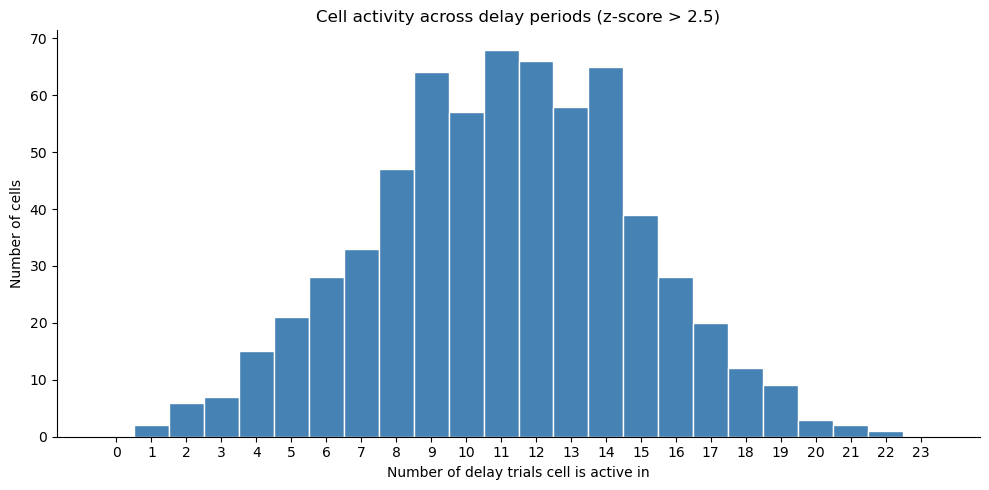

In [49]:
# Histogram: number of cells active in N delay trials
cell_cols = [c for c in calciumData.columns if str(c).startswith('cell_')]
total_trials = len(delay_df)

trial_counts = []
for cell in cell_cols:
    count = sum(cell in row for row in active_cells_summary_df['active_cells'])
    trial_counts.append(count)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(trial_counts, bins=range(0, total_trials + 2), align='left', color='steelblue', edgecolor='white')
ax.set_xlabel('Number of delay trials cell is active in')
ax.set_ylabel('Number of cells')
ax.set_title('Cell activity across delay periods (z-score > 2.5)')
ax.set_xticks(range(0, total_trials + 1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

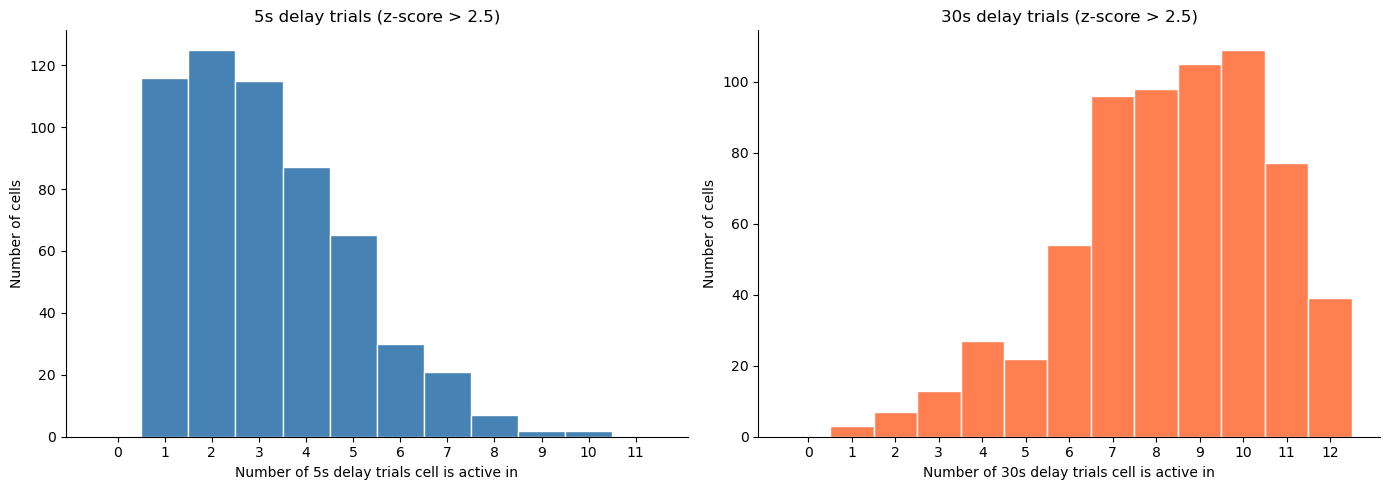

In [54]:
trial_counts_5s = []
trial_counts_30s = []

trials_5s = delay_df[delay_df['delay_duration_s'] < 10]['trial_number'].tolist()
trials_30s = delay_df[delay_df['delay_duration_s'] > 10]['trial_number'].tolist()

for cell in cell_cols:
    count_5s = sum(cell in row for row in active_cells_summary_df[active_cells_summary_df['trial_number'].isin(trials_5s)]['active_cells'])
    count_30s = sum(cell in row for row in active_cells_summary_df[active_cells_summary_df['trial_number'].isin(trials_30s)]['active_cells'])
    trial_counts_5s.append(count_5s)
    trial_counts_30s.append(count_30s)
    
trial_counts_5s_active = [x for x in trial_counts_5s if x > 0]
trial_counts_30s_active = [x for x in trial_counts_30s if x > 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(trial_counts_5s_active, bins=range(0, len(trials_5s) + 2), align='left', color='steelblue', edgecolor='white')
ax1.set_xlabel('Number of 5s delay trials cell is active in')
ax1.set_ylabel('Number of cells')
ax1.set_title('5s delay trials (z-score > 2.5)')
ax1.set_xticks(range(0, len(trials_5s) + 1))
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2.hist(trial_counts_30s_active, bins=range(0, len(trials_30s) + 2), align='left', color='coral', edgecolor='white')
ax2.set_xlabel('Number of 30s delay trials cell is active in')
ax2.set_ylabel('Number of cells')
ax2.set_title('30s delay trials (z-score > 2.5)')
ax2.set_xticks(range(0, len(trials_30s) + 1))
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('/Users/louisflagel/Downloads/Contractor Data Analysis/MiniscopeRecordingAlignment/388/histogram_by_delay.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
# cells active in all delay periods 
cellsActiveInAllDataFrames=sorted(set.intersection(*map(set, active_cells_summary_df["active_cells"])))
print(cellsActiveInAllDataFrames) 
# cells most active across delay periods
cell_counts = Counter(cell for cells in active_cells_summary_df["active_cells"] for cell in cells)
sorted_cells = cell_counts.most_common()
print(sorted_cells)

[]
[('cell_131', 22), ('cell_403', 21), ('cell_602', 21), ('cell_196', 20), ('cell_382', 20), ('cell_746', 20), ('cell_115', 19), ('cell_257', 19), ('cell_303', 19), ('cell_349', 19), ('cell_497', 19), ('cell_575', 19), ('cell_711', 19), ('cell_654', 19), ('cell_715', 19), ('cell_471', 18), ('cell_524', 18), ('cell_553', 18), ('cell_569', 18), ('cell_585', 18), ('cell_604', 18), ('cell_644', 18), ('cell_268', 18), ('cell_285', 18), ('cell_422', 18), ('cell_460', 18), ('cell_508', 18), ('cell_374', 17), ('cell_387', 17), ('cell_484', 17), ('cell_685', 17), ('cell_713', 17), ('cell_752', 17), ('cell_778', 17), ('cell_782', 17), ('cell_787', 17), ('cell_104', 17), ('cell_225', 17), ('cell_234', 17), ('cell_447', 17), ('cell_506', 17), ('cell_528', 17), ('cell_533', 17), ('cell_565', 17), ('cell_683', 17), ('cell_221', 17), ('cell_726', 17), ('cell_27', 16), ('cell_71', 16), ('cell_160', 16), ('cell_245', 16), ('cell_261', 16), ('cell_317', 16), ('cell_406', 16), ('cell_414', 16), ('cell_4

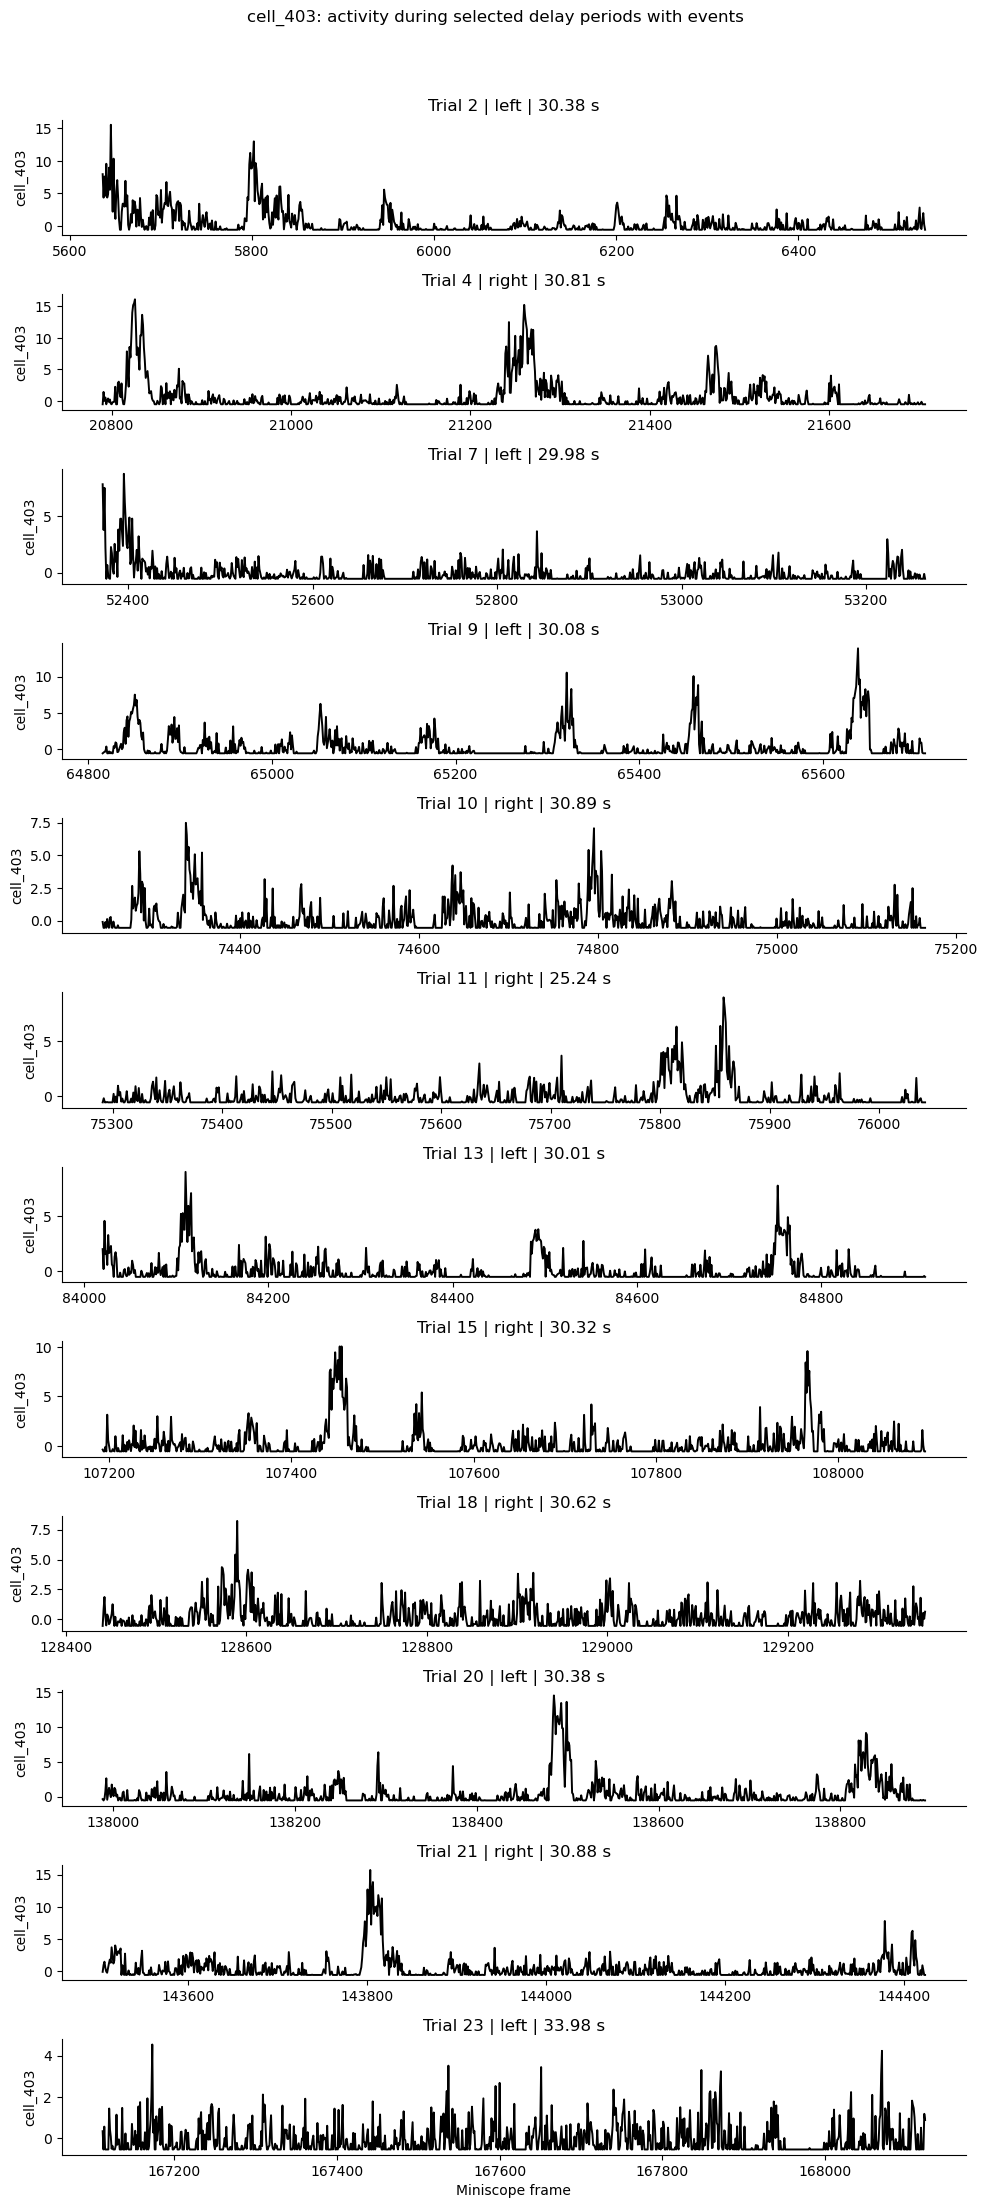

In [61]:
plot_input_cell_active_delays_stacked(
    cell="cell_403",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df['delay_duration_s']>6],
    active_cells_summary_df=active_cells_summary_df,
)


In [72]:
jaccard_df_5_sec, binned_df_5_sec, meta_df_5_sec = correlate_input_cell_across_delays(
    cell="cell_403",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df["delay_duration_s"] < 6],
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=20,
    binarize_mode="any",
    similarity_mode="jaccard",
)


jaccard_df_5_sec

,T1,T3,T5,T6,T12,T16,T17,T19,T22
T1,1.000000,0.333333,0.285714,0.600000,0.600000,0.400000,1.000000,0.166667,0.500000
T3,0.333333,1.000000,0.500000,0.142857,0.333333,0.166667,0.333333,0.400000,0.125000
T5,0.285714,0.500000,1.000000,0.500000,0.285714,0.142857,0.285714,0.142857,0.428571
T6,0.600000,0.142857,0.500000,1.000000,0.333333,0.400000,0.600000,0.000000,0.800000
T12,0.600000,0.333333,0.285714,0.333333,1.000000,0.400000,0.600000,0.400000,0.500000
T16,0.400000,0.166667,0.142857,0.400000,0.400000,1.000000,0.400000,0.200000,0.600000
T17,1.000000,0.333333,0.285714,0.600000,0.600000,0.400000,1.000000,0.166667,0.500000
T19,0.166667,0.400000,0.142857,0.000000,0.400000,0.200000,0.166667,1.000000,0.142857
T22,0.500000,0.125000,0.428571,0.800000,0.500000,0.600000,0.500000,0.142857,1.000000


In [74]:
jaccard_df_30_sec, binned_df_30_sec, meta_df_30_sec = correlate_input_cell_across_delays(
    cell="cell_403",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df["delay_duration_s"] > 6],
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=20,
    binarize_mode="any",
    similarity_mode="jaccard",
)


jaccard_df_30_sec

,T2,T4,T7,T9,T10,T11,T13,T15,T18,T20,T21,T23
T2,1.000000,0.250000,0.133333,0.333333,0.333333,0.055556,0.176471,0.210526,0.238095,0.173913,0.363636,0.055556
T4,0.250000,1.000000,0.187500,0.304348,0.304348,0.050000,0.222222,0.136364,0.120000,0.260870,0.280000,0.166667
T7,0.133333,0.187500,1.000000,0.062500,0.062500,0.000000,0.285714,0.090909,0.071429,0.066667,0.117647,0.000000
T9,0.333333,0.304348,0.062500,1.000000,0.333333,0.117647,0.052632,0.210526,0.083333,0.227273,0.250000,0.117647
T10,0.333333,0.304348,0.062500,0.333333,1.000000,0.266667,0.111111,0.045455,0.238095,0.173913,0.363636,0.055556
T11,0.055556,0.050000,0.000000,0.117647,0.266667,1.000000,0.100000,0.166667,0.133333,0.058824,0.050000,0.111111
T13,0.176471,0.222222,0.285714,0.052632,0.111111,0.100000,1.000000,0.363636,0.125000,0.117647,0.100000,0.222222
T15,0.210526,0.136364,0.090909,0.210526,0.045455,0.166667,0.363636,1.000000,0.105263,0.294118,0.086957,0.272727
T18,0.238095,0.120000,0.071429,0.083333,0.238095,0.133333,0.125000,0.105263,1.000000,0.250000,0.272727,0.000000
T20,0.173913,0.260870,0.066667,0.227273,0.173913,0.058824,0.117647,0.294118,0.250000,1.000000,0.260870,0.125000


In [75]:
avg_corr_5_sec = jaccard_df_5_sec.where(np.triu(np.ones(jaccard_df_5_sec.shape, dtype=bool), k=1)).stack().mean()
avg_corr_5_sec

np.float64(0.38098544973544973)

In [76]:
avg_corr_30_sec = jaccard_df_30_sec.where(np.triu(np.ones(jaccard_df_30_sec.shape, dtype=bool), k=1)).stack().mean()
avg_corr_30_sec

np.float64(0.16790340738359255)

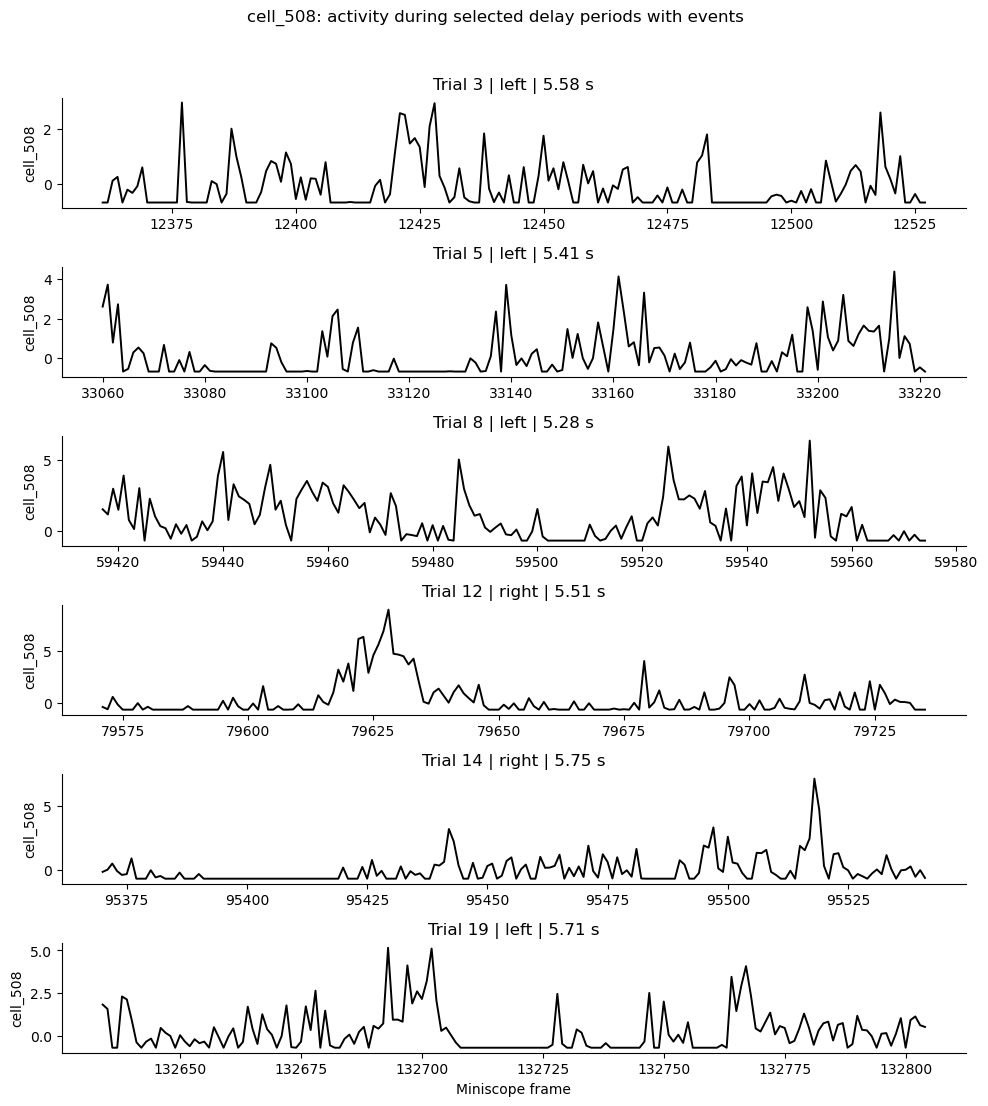

In [93]:
plot_input_cell_active_delays_stacked(
    cell="cell_508",
    calciumData=calciumData,
    delay_periods_df=delay_df[delay_df['delay_duration_s']<6],
    active_cells_summary_df=active_cells_summary_df,
)

In [ ]:
## heatmaps for binarized cell activity across delay periods 

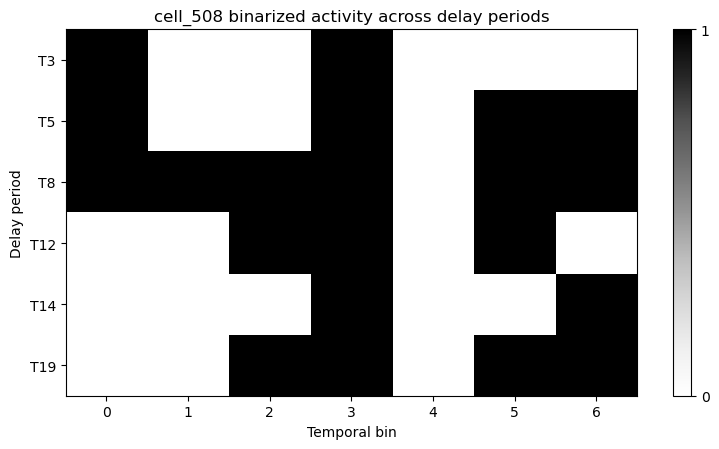

In [92]:
cell = "cell_508"
delay_subset = delay_df[delay_df["delay_duration_s"] < 6]   # or > 6

_, binned_df, meta_df = correlate_input_cell_across_delays(
    cell=cell,
    calciumData=calciumData,
    delay_periods_df=delay_subset,
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=20,
    binarize_mode="any",
)

fig, ax = plt.subplots(figsize=(8, 0.6 * len(binned_df) + 1))
im = ax.imshow(binned_df.to_numpy(), aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=1)

ax.set_yticks(np.arange(len(binned_df.index)))
ax.set_yticklabels(binned_df.index)
ax.set_xlabel("Temporal bin")
ax.set_ylabel("Delay period")
ax.set_title(f"{cell} binarized activity across delay periods")

plt.colorbar(im, ax=ax, ticks=[0, 1])
plt.tight_layout()
plt.show()


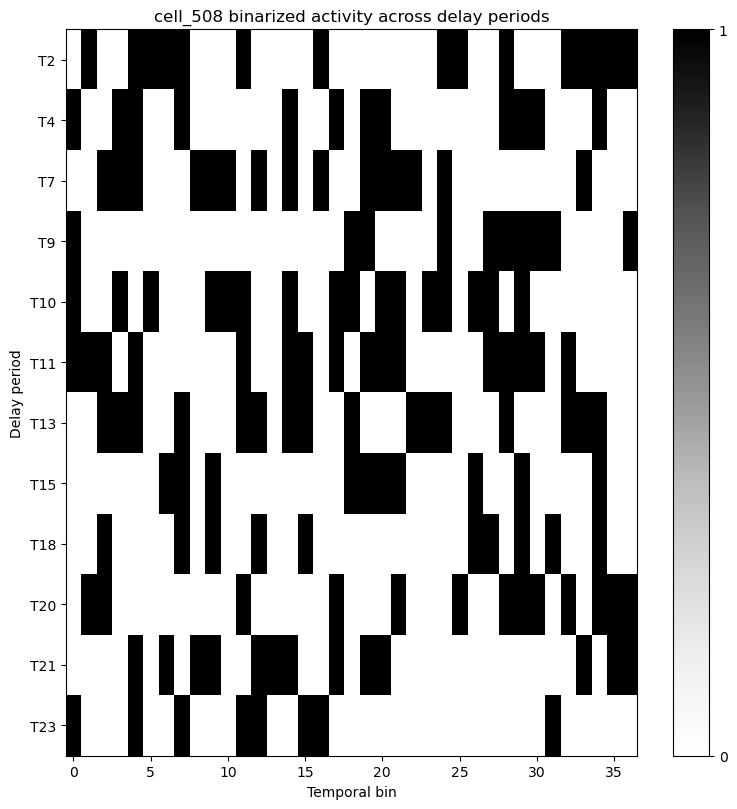

In [90]:
cell = "cell_508"
delay_subset = delay_df[delay_df["delay_duration_s"] > 6]   # or > 6

_, binned_df, meta_df = correlate_input_cell_across_delays(
    cell=cell,
    calciumData=calciumData,
    delay_periods_df=delay_subset,
    active_cells_summary_df=active_cells_summary_df,
    threshold=2.5,
    bin_width_frames=20,
    binarize_mode="any",
)

fig, ax = plt.subplots(figsize=(8, 0.6 * len(binned_df) + 1))
im = ax.imshow(binned_df.to_numpy(), aspect="auto", interpolation="nearest", cmap="Greys", vmin=0, vmax=1)

ax.set_yticks(np.arange(len(binned_df.index)))
ax.set_yticklabels(binned_df.index)
ax.set_xlabel("Temporal bin")
ax.set_ylabel("Delay period")
ax.set_title(f"{cell} binarized activity across delay periods")

plt.colorbar(im, ax=ax, ticks=[0, 1])
plt.tight_layout()
plt.show()

In [82]:
active_cells_all = [cell for cell, _ in sorted_cells]   # or use cellsActiveInAllDataFrames

rows = []

for cell in active_cells_all:
    jaccard_df_5, _, meta_df_5 = correlate_input_cell_across_delays(
        cell=cell,
        calciumData=calciumData,
        delay_periods_df=delay_df[delay_df["delay_duration_s"] < 6],
        active_cells_summary_df=active_cells_summary_df,
        threshold=2.5,
        bin_width_frames=20,
        binarize_mode="any",
        similarity_mode="jaccard",
    )

    jaccard_df_30, _, meta_df_30 = correlate_input_cell_across_delays(
        cell=cell,
        calciumData=calciumData,
        delay_periods_df=delay_df[delay_df["delay_duration_s"] > 6],
        active_cells_summary_df=active_cells_summary_df,
        threshold=2.5,
        bin_width_frames=20,
        binarize_mode="any",
        similarity_mode="jaccard",
    )

    avg_5 = np.nan if jaccard_df_5 is None else jaccard_df_5.where(
        np.triu(np.ones(jaccard_df_5.shape, dtype=bool), k=1)
    ).stack().mean()

    avg_30 = np.nan if jaccard_df_30 is None else jaccard_df_30.where(
        np.triu(np.ones(jaccard_df_30.shape, dtype=bool), k=1)
    ).stack().mean()

    rows.append({
        "cell": cell,
        "n_delay_periods_active_total": cell_counts[cell],
        "n_5s_delays_used": 0 if meta_df_5 is None else len(meta_df_5),
        "n_30s_delays_used": 0 if meta_df_30 is None else len(meta_df_30),
        "avg_jaccard_5_sec": avg_5,
        "avg_jaccard_30_sec": avg_30,
    })

jaccard_summary_df = pd.DataFrame(rows)
jaccard_summary_df


Need at least 2 delay periods to compute similarities for cell_509.
Need at least 2 delay periods to compute similarities for cell_75.
Need at least 2 delay periods to compute similarities for cell_177.
Need at least 2 delay periods to compute similarities for cell_287.
Need at least 2 delay periods to compute similarities for cell_689.
Need at least 2 delay periods to compute similarities for cell_170.
No matching delay periods found for cell_8.
Need at least 2 delay periods to compute similarities for cell_62.
Need at least 2 delay periods to compute similarities for cell_143.
Need at least 2 delay periods to compute similarities for cell_187.
No matching delay periods found for cell_212.
Need at least 2 delay periods to compute similarities for cell_272.
Need at least 2 delay periods to compute similarities for cell_371.
Need at least 2 delay periods to compute similarities for cell_511.
Need at least 2 delay periods to compute similarities for cell_554.
Need at least 2 delay period

,cell,n_delay_periods_active_total,n_5s_delays_used,n_30s_delays_used,avg_jaccard_5_sec,avg_jaccard_30_sec
0,cell_131,22,10,12,0.091481,0.141851
1,cell_403,21,9,12,0.380985,0.167903
2,cell_602,21,10,11,0.245926,0.129626
3,cell_196,20,8,12,0.220833,0.183782
4,cell_382,20,8,12,0.375680,0.220674
...,...,...,...,...,...,...
646,cell_219,2,0,2,NaN,0.000000
647,cell_535,2,0,2,NaN,0.000000
648,cell_606,2,1,1,NaN,NaN
649,cell_549,1,0,1,NaN,NaN


In [84]:
jaccard_summary_df = jaccard_summary_df.sort_values("avg_jaccard_5_sec", ascending=False).reset_index(drop=True)
jaccard_summary_df

,cell,n_delay_periods_active_total,n_5s_delays_used,n_30s_delays_used,avg_jaccard_5_sec,avg_jaccard_30_sec
0,cell_442,11,2,9,1.000000,0.043981
1,cell_679,11,2,9,0.857143,0.212012
2,cell_11,9,2,7,0.666667,0.223636
3,cell_712,9,2,7,0.666667,0.061699
4,cell_776,9,2,7,0.666667,0.065319
...,...,...,...,...,...,...
646,cell_219,2,0,2,NaN,0.000000
647,cell_535,2,0,2,NaN,0.000000
648,cell_606,2,1,1,NaN,NaN
649,cell_549,1,0,1,NaN,NaN


In [88]:
# sort first by more than 5 delay periods in "n_5s_delays_used" then sort by highest correlation 
jaccard_summary_df_5filt = (jaccard_summary_df.loc[jaccard_summary_df["n_5s_delays_used"] > 5].sort_values("avg_jaccard_5_sec", ascending=False).reset_index(drop=True))
jaccard_summary_df_5filt




,cell,n_delay_periods_active_total,n_5s_delays_used,n_30s_delays_used,avg_jaccard_5_sec,avg_jaccard_30_sec
0,cell_625,14,7,7,0.458333,0.076804
1,cell_508,18,6,12,0.452222,0.208064
2,cell_27,16,7,9,0.397619,0.166150
3,cell_787,17,6,11,0.393016,0.188806
4,cell_403,21,9,12,0.380985,0.167903
...,...,...,...,...,...,...
57,cell_746,20,8,12,0.142857,0.159960
58,cell_234,17,6,11,0.122222,0.043190
59,cell_748,14,7,7,0.117234,0.125388
60,cell_654,19,7,12,0.097619,0.142879
